# Political Alignment and Divorce Law

This examples is based on a [case study in exploratory data analysis](https://allendowney.github.io/PoliticalAlignmentCaseStudy/).
This case study is part of the [*Elements of Data Science*](https://allendowney.github.io/ElementsOfDataScience/) curriculum.
[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/PoliticalAlignmentCaseStudy/blob/v1/examples/divorce.ipynb).

In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

download("https://github.com/AllenDowney/PoliticalAlignmentCaseStudy/raw/v1/utils.py")

The following cell installs the `empiricaldist` library if necessary.

In [2]:
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

If everything we need is installed, the following cell should run without error.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from empiricaldist import Pmf

The following cells import functions from previous chapters we will use again.

In [4]:
from utils import values, decorate, make_lowess, plot_series_lowess

The following cells downloads the data file.

In [5]:
download(
    "https://github.com/AllenDowney/PoliticalAlignmentCaseStudy/raw/v1/gss_pacs_resampled.hdf"
)

Now we'll load the first resampled `DataFrame`.

In [6]:
datafile = "gss_pacs_resampled.hdf"
gss = pd.read_hdf(datafile, "gss0")
gss.shape

(72390, 207)

The column we'll look at is `divlaw`, which contains responses to [this question](https://gssdataexplorer.norc.org/variables/627/vshow):

> Should divorce in this country be easier or more difficult to obtain than it is now?

In [7]:
varname = "divlaw"
column = gss[varname]
column.tail()

72385    NaN
72386    NaN
72387    NaN
72388    2.0
72389    1.0
Name: divlaw, dtype: float64

The following cell shows the numerical values and the text of the responses they stand for.

In [8]:
responses = [1, 2, 3]

labels = [
    "Easier",
    "More difficult",
    "Stay as is",
]

In [9]:
column.value_counts(dropna=False).sort_index()

1.0    11733
2.0    18735
3.0     8308
NaN    33614
Name: divlaw, dtype: int64

Here's what the distribution looks like.

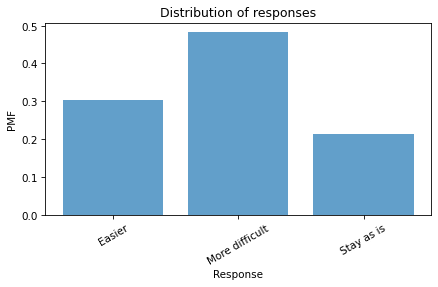

In [10]:
pmf = Pmf.from_seq(column)
pmf.bar(alpha=0.7)

decorate(xlabel="Response", ylabel="PMF", title="Distribution of responses")
plt.xticks(responses, labels, rotation=30);

These results are an average over the entire interval of the survey, so you should not interpret them as a current condition.

## Responses over time

If we make a cross tabulation of `year` and the variable of interest, we get the distribution of responses over time.

In [11]:
xtab = pd.crosstab(gss["year"], column, normalize="index")
xtab.head()

divlaw,1.0,2.0,3.0
year,,,
1974,0.345442,0.442308,0.212251
1975,0.288421,0.503158,0.208421
1976,0.302076,0.506800,0.191124
1977,0.300891,0.527759,0.171350
1978,0.297390,0.440934,0.261676


Now we can plot the results.

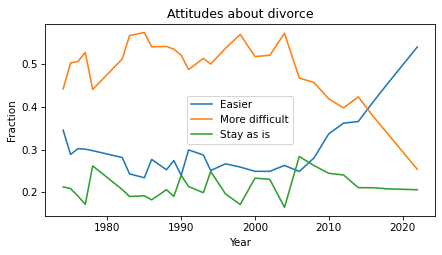

In [12]:
for response, label in zip(responses, labels):
    xtab[response].plot(label=label)

decorate(xlabel="Year",
         ylabel="Fraction",
         title="Attitudes about divorce")

## Political alignment

To explore the relationship between these responses and political alignment, we'll recode political alignment into three groups:

In [13]:
d_polviews = {
    1: "Liberal",
    2: "Liberal",
    3: "Liberal",
    4: "Moderate",
    5: "Conservative",
    6: "Conservative",
    7: "Conservative",
}

Now we can use `replace` and store the result as a new column in the `DataFrame`.

In [14]:
gss["polviews3"] = gss["polviews"].replace(d_polviews)

With this scale, there are roughly the same number of people in each group.

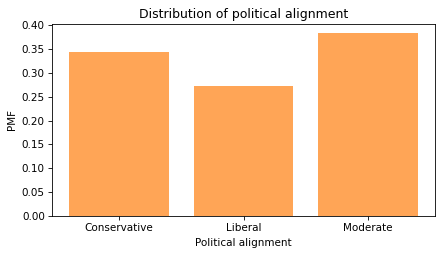

In [15]:
pmf = Pmf.from_seq(gss["polviews3"])
pmf.bar(color="C1", alpha=0.7)

decorate(
    xlabel="Political alignment",
    ylabel="PMF",
    title="Distribution of political alignment",
)

## Group by political alignment

Now we can use `groupby` to group the respondents by political alignment.

In [16]:
by_polviews = gss.groupby("polviews3")

Here's a dictionary that maps from each group to a color.

In [17]:
muted = sns.color_palette("muted", 5)
color_map = {"Conservative": muted[3], "Moderate": muted[4], "Liberal": muted[0]}

Now I'll make a PMF of responses for each group.

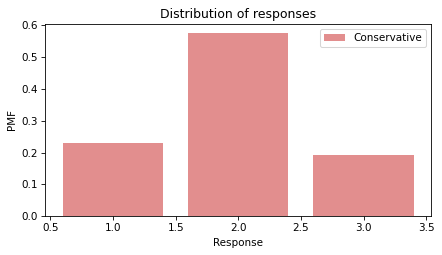

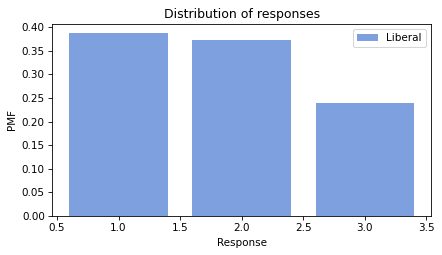

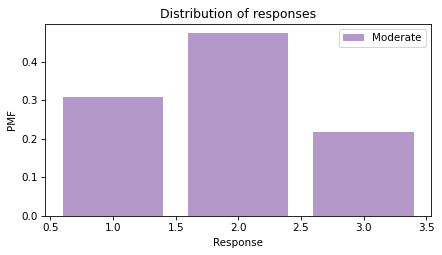

In [18]:
for name, group in by_polviews:
    plt.figure()
    pmf = Pmf.from_seq(group[varname])
    pmf.bar(label=name, color=color_map[name], alpha=0.7)

    decorate(xlabel="Response", ylabel="PMF", title="Distribution of responses")

But again, these results are an average over the interval of the survey, so you should not interpret them as a current condition.

## Recode

To quantify changes in these responses over time, one option is to put them on a numerical scale and compute the mean.
Another option is to compute the percentage who choose a particular response or set of responses.
Since the majority response is "Always wrong", that's the response we'll track.
We'll use `replace` to recode the values so "Always wrong" is `1` and all other responses are `0`.

In [19]:
d_recode = {1: 0, 2: 1, 3: 0}

gss["recoded"] = column.replace(d_recode)
gss["recoded"].name = varname

We can use `value_counts` to confirm that it worked.

In [20]:
gss["recoded"].value_counts(dropna=False)

NaN    33614
0.0    20041
1.0    18735
Name: divlaw, dtype: int64

Now if we compute the mean, we can interpret it as "the fraction of respondents who think divorce should be more difficult".
Multiplying by `100` makes it a percentage.

In [21]:
gss["recoded"].mean() * 100

48.31596864039612

Note that the `Series` method `mean` drops `NaN` values before computing the mean.
The NumPy function `mean` does not.

## Average by group

We can use `by_polviews` to compute the mean of the recoded variable in each group, and multiply by `100` to get a percentage.

In [22]:
means = by_polviews["recoded"].mean() * 100
means

polviews3
Conservative    57.645939
Liberal         37.325430
Moderate        47.405560
Name: divlaw, dtype: float64

By default, the group names are in alphabetical order.
To get the values in a particular order, we can use the group names as an index:

In [23]:
groups = ["Conservative", "Moderate", "Liberal"]
means[groups]

polviews3
Conservative    57.645939
Moderate        47.405560
Liberal         37.325430
Name: divlaw, dtype: float64

Now we can make a bar plot with color-coded bars:

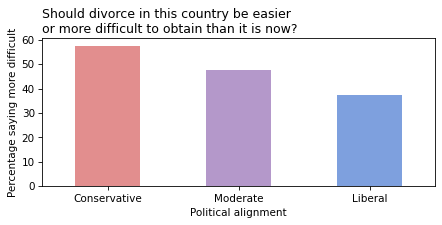

In [24]:
colors = color_map.values()
means[groups].plot(kind="bar", color=colors, alpha=0.7, label="")

ylabel = "Percentage saying more difficult"
title = """Should divorce in this country be easier
or more difficult to obtain than it is now?"""

decorate(
    xlabel="Political alignment",
    ylabel=ylabel,
)

plt.xticks(rotation=0)
plt.title(title, loc='left');

## Time series

We can use `groupby` to group responses by year.

In [25]:
by_year = gss.groupby("year")

From the result we can select the recoded variable and compute the percentage that responded "Always wrong".

In [26]:
time_series = by_year["recoded"].mean() * 100
time_series

year
1972          NaN
1973          NaN
1974    44.230769
1975    50.315789
1976    50.680029
1977    52.775874
1978    44.093407
1980          NaN
1982    51.240135
1983    56.735236
1984          NaN
1985    57.464213
1986    54.107649
1987          NaN
1988    54.171301
1989    53.571429
1990    52.109464
1991    48.770492
1993    51.392891
1994    50.054645
1996    53.749316
1998    57.003444
2000    51.821192
2002    52.092511
2004    57.278107
2006    46.781790
2008    45.729814
2010    41.885626
2012    39.767055
2014    42.367601
2016    37.828763
2018    33.694084
2021          NaN
2022    25.367363
Name: divlaw, dtype: float64

And we can plot the results with the data points themselves as circles and a local regression model as a line.

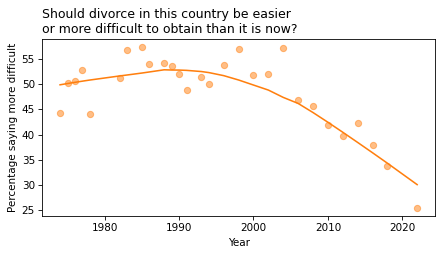

In [33]:
plot_series_lowess(time_series, "C1")

decorate(
    xlabel="Year",
    ylabel=ylabel,
    legend=False
)
plt.title(title, loc='left')
plt.tight_layout()
plt.savefig('divorce1.png', dpi=300)

## Time series by group

So far, we have grouped by `polviews3` and computed the mean of the variable of interest in each group.
Then we grouped by `year` and computed the mean for each year.
Now we'll use `pivot_table` to compute the mean in each group for each year.

In [28]:
table = gss.pivot_table(
    values="recoded", index="year", columns="polviews3", aggfunc="mean"
)

In [29]:
table.head()

polviews3,Conservative,Liberal,Moderate
year,,,
1974,0.584158,0.324706,0.414062
1975,0.544081,0.459207,0.503861
1976,0.572792,0.398936,0.523364
1977,0.601399,0.401914,0.559083
1978,0.510870,0.315403,0.482176


The result is a table that has years running down the rows and political alignment running across the columns.

Each entry in the table is the mean of the variable of interest for a given group in a given year.

## Plotting the results

Now let's see the results.

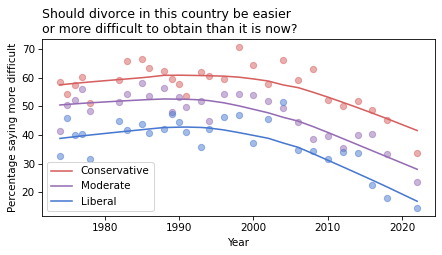

In [34]:
for group in groups:
    series = table[group] * 100
    plot_series_lowess(series, color_map[group])
    
decorate(
    xlabel="Year",
    ylabel=ylabel,
)
plt.title(title, loc='left')
plt.tight_layout()
plt.savefig('divorce2.png', dpi=300)

## Resampling

The figures we have generated so far in this notebook are based on a single resampling of the GSS data.  Some of the features we see in these figures might be due to random sampling rather than actual changes in the world.
By generating the same figures with different resampled datasets, we can get a sense of how much variation there is due to random sampling.
To make that easier, the following function contains the code from the previous analysis all in one place.

In [31]:
def plot_by_polviews(gss, varname):
    """Plot mean response by polviews and year.

    gss: DataFrame
    varname: string column name
    """
    gss["polviews3"] = gss["polviews"].replace(d_polviews)

    column = gss[varname]
    gss["recoded"] = column.replace(d_recode)

    table = gss.pivot_table(
        values="recoded", index="year", columns="polviews3", aggfunc="mean"
    )

    for group in groups:
        series = table[group] * 100
        plot_series_lowess(series, color_map[group])

    decorate(
        xlabel="Year",
        ylabel=ylabel,
    )
    plt.title(title, loc='left');

Now we can loop through the three resampled datasets and generate a figure for each one.

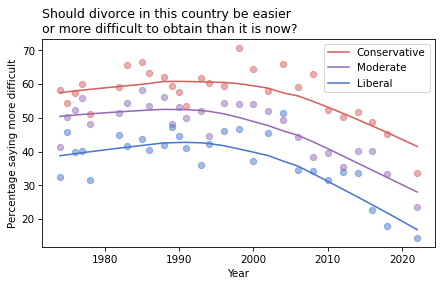

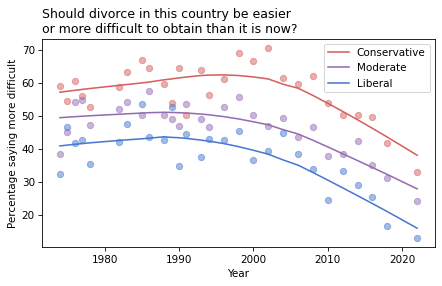

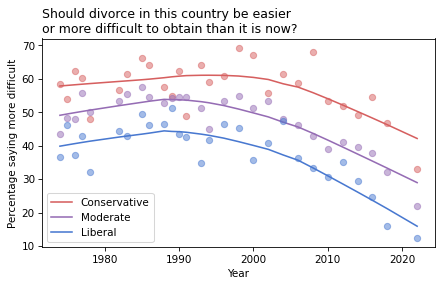

In [32]:
datafile = "gss_pacs_resampled.hdf"

for key in ["gss0", "gss1", "gss2"]:
    df = pd.read_hdf(datafile, key)

    plt.figure()
    plot_by_polviews(df, varname)

If you see an effect that is consistent in all three figures, it is less likely to be due to random sampling.
If it varies from one resampling to the next, you should probably not take it too seriously.

Political Alignment Case Study

Copyright 2020 Allen B. Downey

License: [Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)